# Libs

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

# Plot Style

In [2]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#e5e5e0",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#52514e",
    "text.color": "#0b0b0b",
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLOR_EXISTING = "#2a78d6"  # categorical slot 1 (blue)
COLOR_NEW = "#eb6834"  # categorical slot 2 (orange)
COLOR_AQUA = "#1baf7a"  # categorical slot 3
COLOR_YELLOW = "#eda100"  # categorical slot 4
COLOR_NEUTRAL = "#8a8a85"  # muted reference lines
SEQUENTIAL_BLUES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]
CANDIDATE_COLORS = {
    "final_model": COLOR_EXISTING,
    "recency_rule": COLOR_NEW,
    "rfm_rule": COLOR_AQUA,
    "random": COLOR_NEUTRAL,
}

# Helpers

In [3]:
def apply_episode_cooldown(active_grid, cooldown_days):
    """Select one training snapshot per eligibility episode.

    Reused unchanged from notebooks/06-08 -- see those notebooks for
    the full rationale.

    Args:
        active_grid: Active rows with customer_id and
            snapshot_date columns.
        cooldown_days: Minimum gap in days between two training
            snapshots of the same customer (C).

    Returns:
        The subset of active_grid rows selected as training
        snapshots.
    """
    cooldown = pd.Timedelta(days=cooldown_days)
    ordered = active_grid.sort_values(["customer_id", "snapshot_date"])
    selected_index = []
    for _, rows in ordered.groupby("customer_id"):
        next_allowed = None
        for row in rows.itertuples():
            allowed = next_allowed is None or row.snapshot_date >= (
                next_allowed
            )
            if allowed:
                selected_index.append(row.Index)
                next_allowed = row.snapshot_date + cooldown
    return active_grid.loc[selected_index]

In [4]:
LOG_FEATURES = [
    "monetary_so_far", "avg_order_value_so_far", "tenure_days",
    "mean_gap_so_far", "recency_to_typical_gap", "activity_last_90d",
    "distinct_products_so_far", "cancel_count_so_far",
    "frequency_so_far",
]


def prepare_features(df, features):
    """Select feature columns, log1p-transforming the skewed ones.

    Reused unchanged from notebooks/08_modeling.ipynb (Section 8.1's
    note on feature scaling).

    Args:
        df: DataFrame containing `features`.
        features: List of feature column names to select.

    Returns:
        A new DataFrame with the same columns, skewed ones log1p-
        transformed.
    """
    X = df[features].copy()
    for col in features:
        if col in LOG_FEATURES:
            X[col] = np.log1p(X[col])
    return X

In [5]:
def precision_at_k(y_true, scores, k_frac):
    """Precision within the top k_frac of ranked scores."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = max(int(round(len(scores) * k_frac)), 1)
    top_idx = np.argsort(-scores)[:k]
    return y_true[top_idx].mean()


def lift_at_k(y_true, scores, k_frac):
    """Lift of the top k_frac segment over the overall base rate."""
    y_true = np.asarray(y_true)
    base_rate = y_true.mean()
    return precision_at_k(y_true, scores, k_frac) / base_rate


def gain_at_k(y_true, scores, k_frac):
    """Share of all positives captured within the top k_frac."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = max(int(round(len(scores) * k_frac)), 1)
    top_idx = np.argsort(-scores)[:k]
    return y_true[top_idx].sum() / y_true.sum()


def evaluate_ranking(y_true, scores, k_frac=0.10):
    """Pooled predictive + ranking metrics at one operating point."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    pct = int(k_frac * 100)
    return {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        f"precision_at_{pct}": precision_at_k(y_true, scores, k_frac),
        f"lift_at_{pct}": lift_at_k(y_true, scores, k_frac),
        f"gain_at_{pct}": gain_at_k(y_true, scores, k_frac),
    }

In [6]:
def per_week_ranking_metrics(df, score_col, k_frac=0.10):
    """Ranking metrics computed separately for each scoring week.

    Section 9.3: targeting happens each week, so ranking metrics are
    computed per scoring date (ranking that week's full Scoring
    Population) rather than pooled across the whole test period.

    Args:
        df: Rows with snapshot_date, churn and `score_col` columns.
        score_col: Name of the column holding the risk score.
        k_frac: Operating top-K fraction.

    Returns:
        A DataFrame indexed by snapshot_date with one row per week:
        precision_at_k, lift_at_k, gain_at_k.
    """
    rows = {}
    for week, week_df in df.groupby("snapshot_date"):
        y = week_df["churn"].to_numpy()
        s = week_df[score_col].to_numpy()
        rows[week] = {
            "precision_at_k": precision_at_k(y, s, k_frac),
            "lift_at_k": lift_at_k(y, s, k_frac),
            "gain_at_k": gain_at_k(y, s, k_frac),
        }
    return pd.DataFrame(rows).T

In [7]:
def weekly_business_counts(df, score_col, revenue_col, k_frac):
    """Per-week targeting counts for the business-impact funnel.

    Section 9.6: for a given top-K%, each scoring week contributes
    customers targeted (n), true churners captured (tp), non-
    churners targeted (fp), revenue at risk among targeted churners,
    and that week's total churners (for Recall@K).

    Args:
        df: Rows with snapshot_date, churn, revenue_col and
            `score_col` columns.
        score_col: Name of the column holding the risk score.
        revenue_col: Name of the per-row revenue-at-risk column.
        k_frac: Top-K fraction targeted each week.

    Returns:
        A DataFrame with one row per scoring week: n, tp, fp,
        revenue_at_risk, positives.
    """
    rows = {}
    for week, week_df in df.groupby("snapshot_date"):
        n = max(int(round(len(week_df) * k_frac)), 1)
        top = week_df.sort_values(score_col, ascending=False).head(n)
        is_churn = top["churn"] == 1
        rows[week] = {
            "n": n,
            "tp": int(is_churn.sum()),
            "fp": int((~is_churn).sum()),
            "revenue_at_risk": top.loc[is_churn, revenue_col].sum(),
            "positives": int(week_df["churn"].sum()),
        }
    return pd.DataFrame(rows).T


def business_impact_scenario(counts, e, m, c_contact, c_inc, r):
    """Fold summed weekly counts into one business-impact scenario.

    Sections 9.6-9.9: period totals (summed across scoring weeks)
    feed the revenue/cost formulas; this is a scenario estimate
    under stated assumptions, not a measured causal impact (Online
    Retail II has no treatment/control data -- Section 9.12).

    Args:
        counts: Output of weekly_business_counts, summed with
            .sum() over the period.
        e: Assumed retention effectiveness (share of correctly
            targeted churners who are actually retained).
        m: Assumed gross margin on preserved revenue.
        c_contact: Assumed contact cost per targeted customer.
        c_inc: Assumed incentive cost per redemption.
        r: Assumed cannibalization rate (share of targeted non-
            churners who redeem anyway).

    Returns:
        A dict with n, tp, fp, recall_at_k, revenue_at_risk,
        revenue_preserved, gross_profit_preserved, contact_cost,
        incentive_cost, net_business_impact.
    """
    revenue_preserved = counts["revenue_at_risk"] * e
    gross_profit_preserved = revenue_preserved * m
    contact_cost = counts["n"] * c_contact
    incentive_cost = (counts["tp"] * e + counts["fp"] * r) * c_inc
    net_impact = gross_profit_preserved - contact_cost - incentive_cost
    return {
        "n": counts["n"],
        "tp": counts["tp"],
        "fp": counts["fp"],
        "recall_at_k": counts["tp"] / counts["positives"],
        "revenue_at_risk": counts["revenue_at_risk"],
        "revenue_preserved": revenue_preserved,
        "gross_profit_preserved": gross_profit_preserved,
        "contact_cost": contact_cost,
        "incentive_cost": incentive_cost,
        "net_business_impact": net_impact,
    }

# Load

In [8]:
modeling_dataset = pd.read_parquet(
    "../data/processed/modeling_dataset_h90.parquet"
)
modeling_dataset.shape

(208764, 20)

**Chosen parameters and assumptions.** Inherited from Chapters 6-8:
$H=90$ days, $R_{\max}=136$ days, cooldown $C=90$ days, final model
= Logistic Regression on the Full feature set, $C=0.01$. New
business assumptions for this chapter (Section 3.15's "Assumed"
configuration parameters), clearly stated so they can be varied:
contact cost $c_{\text{contact}}=\pounds0.50$/customer, gross margin
$m=35\%$, incentive cost $c_{\text{inc}}=\pounds5.00$/redemption,
cannibalization $r=20\%$, retention effectiveness
$e \in \{30\%, 40\%, 50\%\}$.

In [9]:
H = 90
COOLDOWN_DAYS = H

RFM_FEATURES = ["recency_days", "frequency_so_far", "monetary_so_far"]
EXTENDED_FEATURES = RFM_FEATURES + [
    "avg_order_value_so_far", "tenure_days", "mean_gap_so_far",
    "recency_to_typical_gap", "activity_last_90d",
]
FULL_FEATURES = EXTENDED_FEATURES + [
    "distinct_products_so_far", "cancel_count_so_far",
    "cancel_value_share_so_far",
]

C_CONTACT = 0.50
MARGIN = 0.35
C_INCENTIVE = 5.00
CANNIBALIZATION = 0.20
EFFECTIVENESS_SCENARIOS = [0.30, 0.40, 0.50]
K_FRACS = [0.10, 0.20, 0.30, 0.40, 0.50]

## 9.1 Evaluation Framework

Evaluate the final system (Chapter~8) on the unseen test period
using three layers: predictive performance, targeting performance,
business-impact estimation. The final model is **refit here from
scratch** (same recipe as Section 8.7: Logistic Regression, Full
feature set, $C=0.01$, trained on the Training Population re-derived
over train+validation) rather than loaded from a saved file, keeping
this notebook self-contained like Chapters 6-8. All evaluation uses
the Scoring Population (every row in `split=="test"`); suppression
is not applied since the historical data contain no real campaigns.

In [10]:
train_df = modeling_dataset[
    (modeling_dataset["split"] == "train")
    & modeling_dataset["in_training_sample"]
]
val_df = modeling_dataset[modeling_dataset["split"] == "validation"]
test_df = modeling_dataset[modeling_dataset["split"] == "test"].copy()

train_start = train_df["snapshot_date"].min()
val_end = val_df["snapshot_date"].max()
refit_pool = modeling_dataset[
    (modeling_dataset["snapshot_date"] >= train_start)
    & (modeling_dataset["snapshot_date"] <= val_end)
    & modeling_dataset["labelable"]
]
refit_rows = apply_episode_cooldown(
    refit_pool[["customer_id", "snapshot_date"]],
    cooldown_days=COOLDOWN_DAYS,
)
refit_train_df = refit_pool.loc[refit_rows.index]

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(
    prepare_features(refit_train_df, FULL_FEATURES)
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
final_model = LogisticRegression(
    max_iter=1000, solver="liblinear", C=0.01
)
final_model.fit(X_train, refit_train_df["churn"])

X_test = scaler.transform(
    imputer.transform(prepare_features(test_df, FULL_FEATURES))
)
test_df["score_final_model"] = final_model.predict_proba(X_test)[:, 1]
print(f"Refit training rows: {len(refit_train_df):,}")
print(f"Test rows: {len(test_df):,} across "
      f"{test_df['snapshot_date'].nunique()} weeks")

Refit training rows: 12,019
Test rows: 24,252 across 10 weeks


/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nba/Documents/projects/customer-churn-prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [11]:
rng = np.random.default_rng(0)
test_df["score_random"] = rng.uniform(size=len(test_df))
test_df["score_recency_rule"] = test_df["recency_days"]

rfm_train_mean = train_df[RFM_FEATURES].mean()
rfm_train_std = train_df[RFM_FEATURES].std()
rfm_z = (test_df[RFM_FEATURES] - rfm_train_mean) / rfm_train_std
test_df["score_rfm_rule"] = (
    rfm_z["recency_days"] - rfm_z["frequency_so_far"]
    - rfm_z["monetary_so_far"]
)

CANDIDATES = {
    "final_model": "score_final_model",
    "recency_rule": "score_recency_rule",
    "rfm_rule": "score_rfm_rule",
    "random": "score_random",
}

for col in test_df["segment"].unique():
    share = (test_df["segment"] == col).mean()
    print(f"segment={col}: {share:.1%} of test rows")

segment=repeat: 86.7% of test rows
segment=one-time: 13.3% of test rows


## 9.2 Classification Performance

ROC-AUC, PR-AUC, Precision/Recall/F1 (at the standard 0.5
probability threshold) on the pooled test set, with the test churn
rate reported alongside PR-AUC as its random reference.

In [12]:
y_test = test_df["churn"].to_numpy()
scores_final = test_df["score_final_model"].to_numpy()
preds_final = (scores_final >= 0.5).astype(int)

classification_metrics = pd.Series({
    "churn_rate": y_test.mean(),
    "roc_auc": roc_auc_score(y_test, scores_final),
    "pr_auc": average_precision_score(y_test, scores_final),
    "precision_at_0.5": precision_score(y_test, preds_final),
    "recall_at_0.5": recall_score(y_test, preds_final),
    "f1_at_0.5": f1_score(y_test, preds_final),
})
classification_metrics.round(3)

churn_rate          0.401
roc_auc             0.764
pr_auc              0.659
precision_at_0.5    0.612
recall_at_0.5       0.649
f1_at_0.5           0.630
dtype: float64

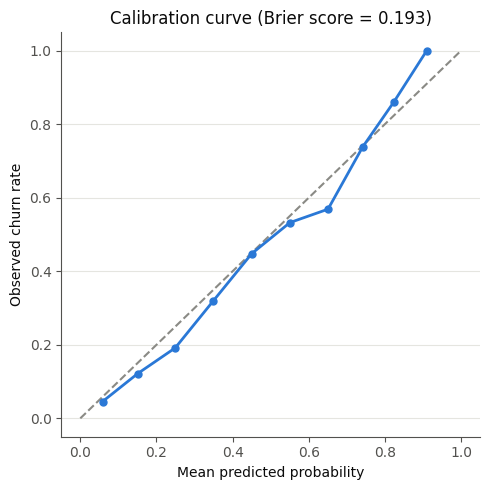

In [13]:
brier = brier_score_loss(y_test, scores_final)
frac_pos, mean_pred = calibration_curve(y_test, scores_final, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle="--", linewidth=1.5)
ax.plot(
    mean_pred, frac_pos, color=COLOR_EXISTING, marker="o",
    markersize=5, linewidth=2,
)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title(f"Calibration curve (Brier score = {brier:.3f})")
fig.tight_layout()
fig.savefig(
    "../latex/figures/ch9_calibration_curve.png", dpi=150,
    bbox_inches="tight",
)
plt.show()

## 9.3 Ranking Performance

Precision@10%, Lift@10% and Gain@10% computed **per scoring week**
(ranking that week's full Scoring Population separately), then
summarized as mean $\pm$ standard deviation across the 10 test
weeks -- not pooled, since the same customers recur across
consecutive weeks (Section 9.1).

In [14]:
weekly_metrics = {
    name: per_week_ranking_metrics(test_df, col)
    for name, col in CANDIDATES.items()
}

ranking_summary = pd.DataFrame({
    name: {
        "precision_at_10_mean": df["precision_at_k"].mean(),
        "precision_at_10_std": df["precision_at_k"].std(),
        "lift_at_10_mean": df["lift_at_k"].mean(),
        "lift_at_10_std": df["lift_at_k"].std(),
        "gain_at_10_mean": df["gain_at_k"].mean(),
        "gain_at_10_std": df["gain_at_k"].std(),
    }
    for name, df in weekly_metrics.items()
}).T
ranking_summary.round(3)

,precision_at_10_mean,precision_at_10_std,lift_at_10_mean,lift_at_10_std,gain_at_10_mean,gain_at_10_std
final_model,0.769,0.047,1.924,0.049,0.193,0.005
recency_rule,0.626,0.056,1.565,0.061,0.157,0.006
rfm_rule,0.718,0.047,1.796,0.049,0.180,0.005
random,0.406,0.045,1.017,0.110,0.102,0.011


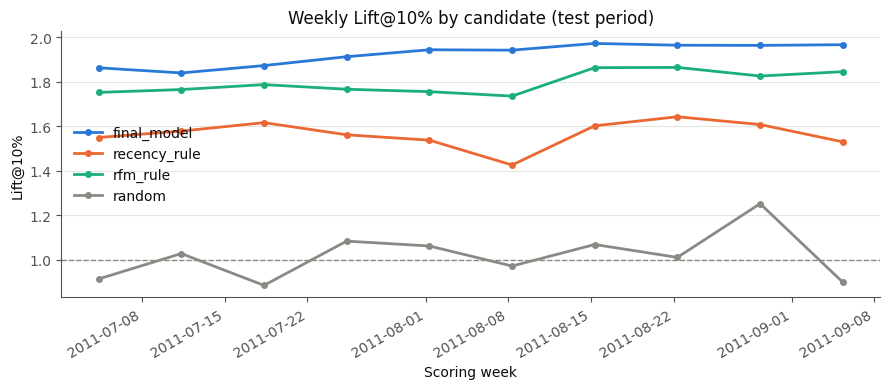

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, df in weekly_metrics.items():
    ax.plot(
        df.index, df["lift_at_k"], label=name,
        color=CANDIDATE_COLORS[name], linewidth=2, marker="o",
        markersize=4,
    )
ax.axhline(1.0, color=COLOR_NEUTRAL, linestyle="--", linewidth=1)
ax.set_ylabel("Lift@10%")
ax.set_xlabel("Scoring week")
ax.set_title("Weekly Lift@10% by candidate (test period)")
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    "../latex/figures/ch9_weekly_lift.png", dpi=150,
    bbox_inches="tight",
)
plt.show()

## 9.4 Risk Band Analysis

Decile customers by the final model's predicted score and compare
actual churn rates across bands, to confirm higher predicted risk
corresponds to higher observed churn.

In [16]:
test_df["risk_decile"] = (
    pd.qcut(
        test_df["score_final_model"].rank(method="first"), 10,
        labels=False,
    )
    + 1
)
risk_band = test_df.groupby("risk_decile").agg(
    customers=("customer_id", "size"),
    churn_rate=("churn", "mean"),
)
risk_band.round(3)

,customers,churn_rate
risk_decile,,
1,2426,0.051
2,2425,0.139
3,2425,0.186
4,2425,0.293
5,2425,0.388
6,2425,0.475
7,2425,0.538
8,2425,0.535
9,2425,0.628


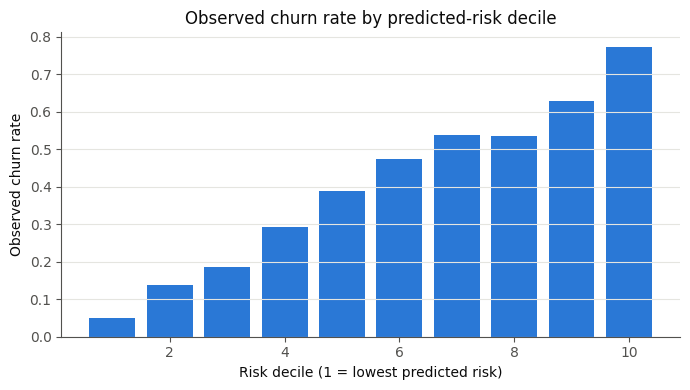

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    risk_band.index, risk_band["churn_rate"], color=SEQUENTIAL_BLUES[2],
)
ax.set_xlabel("Risk decile (1 = lowest predicted risk)")
ax.set_ylabel("Observed churn rate")
ax.set_title("Observed churn rate by predicted-risk decile")
fig.tight_layout()
plt.show()

## 9.5 Customer Revenue at Risk

$\text{AvgPurchaseValue}_i = \text{TotalRevenue}_i \div
\text{PurchaseOccasions}_i$ is already available as
\texttt{avg\_order\_value\_so\_far} (Section 7.6); using one
future purchase-equivalent, $\text{RevenueAtRisk}_i =
\text{AvgPurchaseValue}_i$. All inputs use history up to the
snapshot date only -- this is an estimate of revenue exposure, not
observed lost revenue.

In [18]:
test_df["revenue_at_risk"] = test_df["avg_order_value_so_far"]
test_df["revenue_at_risk"].describe().round(2)

count    24252.00
mean       395.70
std        561.61
min          2.90
25%        197.75
50%        303.58
75%        438.93
max      14844.77
Name: revenue_at_risk, dtype: float64

## 9.6 Business Impact Scenario

For each candidate and each target share $K$, sum weekly targeting
counts (customers targeted $N_K$, true churners captured $TP_K$,
non-churners targeted $FP_K$, revenue at risk among targeted
churners) across the 10 test weeks.

In [19]:
weekly_counts = {
    (name, k): weekly_business_counts(
        test_df, col, "revenue_at_risk", k
    )
    for name, col in CANDIDATES.items()
    for k in K_FRACS
}
period_counts = {
    key: counts.sum() for key, counts in weekly_counts.items()
}

business_scenario_10pct = pd.DataFrame({
    name: period_counts[(name, 0.10)] for name in CANDIDATES
}).T
business_scenario_10pct.round(2)

,n,tp,fp,revenue_at_risk,positives
final_model,2427.0,1867.0,560.0,337903.72,9714.0
recency_rule,2427.0,1521.0,906.0,538397.09,9714.0
rfm_rule,2427.0,1743.0,684.0,498060.34,9714.0
random,2427.0,986.0,1441.0,330372.57,9714.0


## 9.7 Retention Effectiveness Assumption

Retention success is an assumption: Conservative $e=30\%$, Base
$e=40\%$, Optimistic $e=50\%$.
\[
\text{RevenuePreserved} = \text{RevenueAtRisk(targeted churners)}
\times e
\]

In [20]:
revenue_preserved_10pct = pd.DataFrame({
    f"e={e:.0%}": {
        name: period_counts[(name, 0.10)]["revenue_at_risk"] * e
        for name in CANDIDATES
    }
    for e in EFFECTIVENESS_SCENARIOS
})
revenue_preserved_10pct.round(2)

,e=30%,e=40%,e=50%
final_model,101371.12,135161.49,168951.86
recency_rule,161519.13,215358.84,269198.55
rfm_rule,149418.10,199224.14,249030.17
random,99111.77,132149.03,165186.28


## 9.8 Marketing Cost and the Value of the Model

If contact cost per customer is constant, targeting $K\%$ instead
of everyone reduces reach cost by $(1-K)$ -- this saving comes from
\textbf{targeting itself}, identical for every candidate at the
same $K$ (all target the same $N_K$). The model's own contribution
is measured by comparing, at the same $K=10\%$, the churners
captured and revenue preserved across candidates (Base scenario,
$e=40\%$).

In [21]:
cost_comparison = pd.DataFrame({
    name: {
        "customers_targeted": period_counts[(name, 0.10)]["n"],
        "churners_captured": period_counts[(name, 0.10)]["tp"],
        "revenue_preserved_base": (
            period_counts[(name, 0.10)]["revenue_at_risk"] * 0.40
        ),
        "contact_cost": (
            period_counts[(name, 0.10)]["n"] * C_CONTACT
        ),
    }
    for name in CANDIDATES
}).T
cost_comparison.round(2)

,customers_targeted,churners_captured,revenue_preserved_base,contact_cost
final_model,2427.0,1867.0,135161.49,1213.5
recency_rule,2427.0,1521.0,215358.84,1213.5
rfm_rule,2427.0,1743.0,199224.14,1213.5
random,2427.0,986.0,132149.03,1213.5


## 9.9 Net Business Impact

\begin{align*}
\text{GrossProfitPreserved} &= \text{RevenuePreserved} \times m \\
\text{ContactCost} &= N_K \times c_{\text{contact}} \\
\text{IncentiveCost} &= (TP_K \times e + FP_K \times r)
    \times c_{\text{inc}} \\
\text{NetBusinessImpact} &= \text{GrossProfitPreserved}
    - \text{ContactCost} - \text{IncentiveCost}
\end{align*}

In [22]:
net_impact_10pct_base = pd.DataFrame({
    name: business_impact_scenario(
        period_counts[(name, 0.10)], e=0.40, m=MARGIN,
        c_contact=C_CONTACT, c_inc=C_INCENTIVE, r=CANNIBALIZATION,
    )
    for name in CANDIDATES
}).T
net_impact_10pct_base.round(2)

,n,tp,fp,recall_at_k,revenue_at_risk,revenue_preserved,gross_profit_preserved,contact_cost,incentive_cost,net_business_impact
final_model,2427.0,1867.0,560.0,0.19,337903.72,135161.49,47306.52,1213.5,4294.0,41799.02
recency_rule,2427.0,1521.0,906.0,0.16,538397.09,215358.84,75375.59,1213.5,3948.0,70214.09
rfm_rule,2427.0,1743.0,684.0,0.18,498060.34,199224.14,69728.45,1213.5,4170.0,64344.95
random,2427.0,986.0,1441.0,0.10,330372.57,132149.03,46252.16,1213.5,3413.0,41625.66


## 9.10 Scenario Analysis

Full business-impact table across $K$ and $e$ for the final model,
with $m$, $c_{\text{contact}}$, $c_{\text{inc}}$ and $r$ held at
the assumptions stated above; the last column compares net impact
to the recency-rule baseline at the same $K$.

In [23]:
scenario_rows = []
for k in K_FRACS:
    for e in EFFECTIVENESS_SCENARIOS:
        model_result = business_impact_scenario(
            period_counts[("final_model", k)], e, MARGIN, C_CONTACT,
            C_INCENTIVE, CANNIBALIZATION,
        )
        recency_result = business_impact_scenario(
            period_counts[("recency_rule", k)], e, MARGIN, C_CONTACT,
            C_INCENTIVE, CANNIBALIZATION,
        )
        scenario_rows.append({
            "K": f"{int(k * 100)}%",
            "e": f"{int(e * 100)}%",
            "customers": model_result["n"],
            "churners_captured": model_result["tp"],
            "recall_at_k": model_result["recall_at_k"],
            "revenue_at_risk": model_result["revenue_at_risk"],
            "net_impact": model_result["net_business_impact"],
            "net_impact_vs_recency": (
                model_result["net_business_impact"]
                - recency_result["net_business_impact"]
            ),
        })

scenario_analysis = pd.DataFrame(scenario_rows)
scenario_analysis.round(2)

,K,e,customers,churners_captured,recall_at_k,revenue_at_risk,net_impact,net_impact_vs_recency
0,10%,30%,2427.0,1867.0,0.19,337903.72,30905.89,-21224.80
1,10%,40%,2427.0,1867.0,0.19,337903.72,41799.02,-28415.07
2,10%,50%,2427.0,1867.0,0.19,337903.72,52692.15,-35605.34
3,20%,30%,4850.0,3377.0,0.35,794130.67,74420.22,-24452.01
4,20%,40%,4850.0,3377.0,0.35,794130.67,100526.29,-32792.34
5,20%,50%,4850.0,3377.0,0.35,794130.67,126632.37,-41132.68
6,30%,30%,7274.0,4697.0,0.48,1356293.83,129151.35,-13700.23
7,30%,40%,7274.0,4697.0,0.48,1356293.83,174273.14,-18504.64
8,30%,50%,7274.0,4697.0,0.48,1356293.83,219394.92,-23309.05
9,40%,30%,9700.0,5993.0,0.62,1878460.72,179691.88,231.29


## 9.11 Model Comparison

Combine predictive, ranking and business-impact metrics for all
four candidates at the primary operating point ($K=10\%$,
$e=40\%$). No single "best" model emerges from classification
metrics alone -- ranking and business-impact performance matter
more for this targeting use case.

In [24]:
model_comparison_rows = {}
for name, col in CANDIDATES.items():
    pooled = evaluate_ranking(test_df["churn"], test_df[col])
    weekly = weekly_metrics[name]
    impact = business_impact_scenario(
        period_counts[(name, 0.10)], e=0.40, m=MARGIN,
        c_contact=C_CONTACT, c_inc=C_INCENTIVE, r=CANNIBALIZATION,
    )
    model_comparison_rows[name] = {
        "roc_auc": pooled["roc_auc"],
        "pr_auc": pooled["pr_auc"],
        "weekly_lift_at_10_mean": weekly["lift_at_k"].mean(),
        "weekly_lift_at_10_std": weekly["lift_at_k"].std(),
        "net_business_impact_base": impact["net_business_impact"],
    }

model_comparison = pd.DataFrame(model_comparison_rows).T
model_comparison.round(3)

,roc_auc,pr_auc,weekly_lift_at_10_mean,weekly_lift_at_10_std,net_business_impact_base
final_model,0.764,0.659,1.924,0.049,41799.020
recency_rule,0.638,0.531,1.565,0.061,70214.093
rfm_rule,0.736,0.624,1.796,0.049,64344.948
random,0.506,0.404,1.017,0.110,41625.659


## 9.12 Error Analysis and Limitations

Targeting the top 10% by the final model's score (pooled across the
test period), investigate false positives (targeted, did not churn)
and false negatives (missed, did churn) by segment, country, and
wholesale-like status, plus performance by week (seasonal effects).
`country` is not a modeling feature (Section 7.6) and is rejoined
from the raw transaction table for this diagnostic only.

In [25]:
df_retail = pd.read_parquet("../data/raw/online_retail_II.parquet")
customer_country = (
    df_retail.rename(columns={"Customer ID": "customer_id"})
    .dropna(subset=["customer_id"])
    .groupby("customer_id")["Country"]
    .agg(lambda s: s.value_counts().idxmax())
)
test_df["country"] = test_df["customer_id"].map(customer_country)
test_df["is_uk"] = np.where(
    test_df["country"] == "United Kingdom", "UK", "non-UK"
)

revenue_p99 = train_df["monetary_so_far"].quantile(0.99)
test_df["wholesale_like"] = np.where(
    test_df["monetary_so_far"] >= revenue_p99, "wholesale-like", "retail"
)

n_top = max(int(round(len(test_df) * 0.10)), 1)
top_mask = test_df["score_final_model"].rank(
    ascending=False, method="first"
) <= n_top
test_df["targeted"] = top_mask
test_df["error_type"] = np.select(
    [
        top_mask & (test_df["churn"] == 1),
        top_mask & (test_df["churn"] == 0),
        (~top_mask) & (test_df["churn"] == 1),
    ],
    ["true_positive", "false_positive", "false_negative"],
    default="true_negative",
)
test_df["error_type"].value_counts(normalize=True).round(3)

error_type
true_negative     0.577
false_negative    0.323
true_positive     0.077
false_positive    0.023
Name: proportion, dtype: float64

In [26]:
def error_rate_by(df, group_col):
    """Share of false positives and false negatives within each
    group of `group_col`, among that group's targeted/un-targeted
    rows respectively.

    Args:
        df: Test rows with `targeted`, `churn` and `group_col`
            columns.
        group_col: Column name to group by.

    Returns:
        A DataFrame indexed by group value: fp_rate (false positive
        rate among targeted rows), fn_rate (false negative rate
        among non-targeted rows), rows.
    """
    rows = {}
    for value, group in df.groupby(group_col):
        targeted = group[group["targeted"]]
        not_targeted = group[~group["targeted"]]
        rows[value] = {
            "rows": len(group),
            "fp_rate": (
                (targeted["churn"] == 0).mean() if len(targeted) else np.nan
            ),
            "fn_rate": (
                (not_targeted["churn"] == 1).mean()
                if len(not_targeted) else np.nan
            ),
        }
    return pd.DataFrame(rows).T


error_by_segment = error_rate_by(test_df, "segment")
error_by_country = error_rate_by(test_df, "is_uk")
error_by_wholesale = error_rate_by(test_df, "wholesale_like")
print(error_by_segment.round(3))
print(error_by_country.round(3))
print(error_by_wholesale.round(3))

             rows  fp_rate  fn_rate
one-time   3225.0    0.206    0.555
repeat    21027.0    0.253    0.341
           rows  fp_rate  fn_rate
UK      21935.0    0.223    0.363
non-UK   2317.0    0.294    0.325
                   rows  fp_rate  fn_rate
retail          23314.0    0.227    0.372
wholesale-like    938.0      NaN    0.078


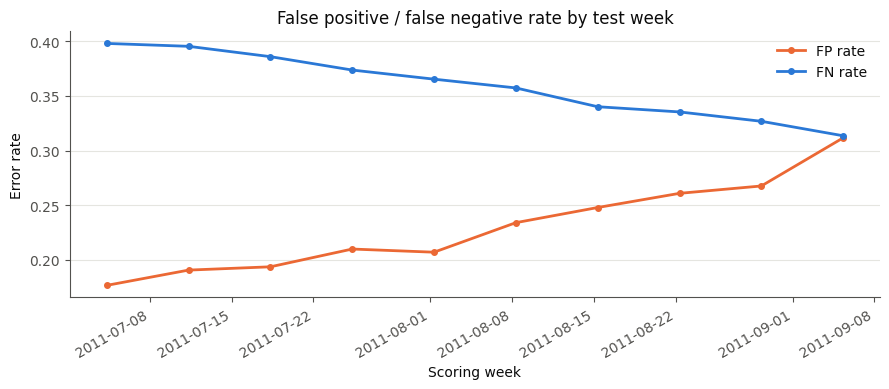

In [27]:
error_by_week = error_rate_by(test_df, "snapshot_date")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    error_by_week.index, error_by_week["fp_rate"], label="FP rate",
    color=COLOR_NEW, linewidth=2, marker="o", markersize=4,
)
ax.plot(
    error_by_week.index, error_by_week["fn_rate"], label="FN rate",
    color=COLOR_EXISTING, linewidth=2, marker="o", markersize=4,
)
ax.set_ylabel("Error rate")
ax.set_xlabel("Scoring week")
ax.set_title("False positive / false negative rate by test week")
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

\textbf{Limitations.} Online Retail II contains no campaign
treatment/control information, so incremental revenue, causal
retention effect and true campaign ROI cannot be identified from
this data. Every business-impact figure in this chapter is a
scenario estimate under the stated assumptions ($e$, $m$,
$c_{\text{contact}}$, $c_{\text{inc}}$, $r$), not a measured
causal effect. The model identifies and prioritizes churn risk; the
retention campaign determines treatment; confirming real-world
incremental impact requires an actual campaign with a
treatment/control design.